In [7]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft
import warnings
warnings.filterwarnings('ignore')

# Consistent style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries loaded successfully!")


Libraries loaded successfully!


---
## **1. Markov Chains & Transition Matrices**

### Discrete-Time Markov Chain

A stochastic process $(X_n)_{n \geq 0}$ on a countable state space $S$ is a **Markov chain** if it satisfies the **Markov property**:

$$\mathbb{P}(X_{n+1} = j \mid X_n = i, X_{n-1}, \ldots, X_0) = \mathbb{P}(X_{n+1} = j \mid X_n = i) = p_{ij}$$

The **one-step transition matrix** $P$ is defined by:

$$P = (p_{ij})_{i,j \in S}, \quad p_{ij} \geq 0, \quad \sum_{j} p_{ij} = 1$$

### n-Step Transition Probabilities

The probability of moving from state $i$ to state $j$ in exactly $n$ steps is:

$$p_{ij}^{(n)} = \mathbb{P}(X_n = j \mid X_0 = i)$$

with $p_{ij}^{(0)} = \delta_{ij}$ and $p_{ij}^{(1)} = p_{ij}$.

The matrix of $n$-step probabilities is denoted $P^{(n)} = (p_{ij}^{(n)})$.


---
## **2. The Chapman-Kolmogorov Equation**

### Statement

For all non-negative integers $m, n$ and all states $i, j$:

$$p_{ij}^{(m+n)} = \sum_{k \in S} p_{ik}^{(m)} \, p_{kj}^{(n)}$$

In matrix notation:

$$P^{(m+n)} = P^{(m)} P^{(n)}$$

Since $P^{(1)} = P$, it follows immediately that:

$$P^{(n)} = P^n$$

### Proof Sketch

Condition on the intermediate state $X_m = k$ and apply the law of total probability:

$$\begin{aligned}
p_{ij}^{(m+n)} &= \mathbb{P}(X_{m+n} = j \mid X_0 = i) \\
&= \sum_{k} \mathbb{P}(X_{m+n} = j \mid X_m = k, X_0 = i) \, \mathbb{P}(X_m = k \mid X_0 = i) \\
&= \sum_{k} \mathbb{P}(X_{m+n} = j \mid X_m = k) \, \mathbb{P}(X_m = k \mid X_0 = i) \quad (\text{Markov property}) \\
&= \sum_{k} p_{kj}^{(n)} \, p_{ik}^{(m)} \quad \checkmark
\end{aligned}$$

### Interpretation

The equation expresses a **semigroup property**: evolving for $m+n$ steps is equivalent to evolving for $m$ steps, then $n$ steps. The intermediate state $k$ is "summed out."


One-step transition matrix P:
[[0.9 0.1]
 [0.4 0.6]]

Chapman-Kolmogorov Verification:
  P^(10) direct:
[[0.80019531 0.19980469]
 [0.79921875 0.20078125]]
  P^3 @ P^7:
[[0.80019531 0.19980469]
 [0.79921875 0.20078125]]
  Max absolute difference: 1.11e-16



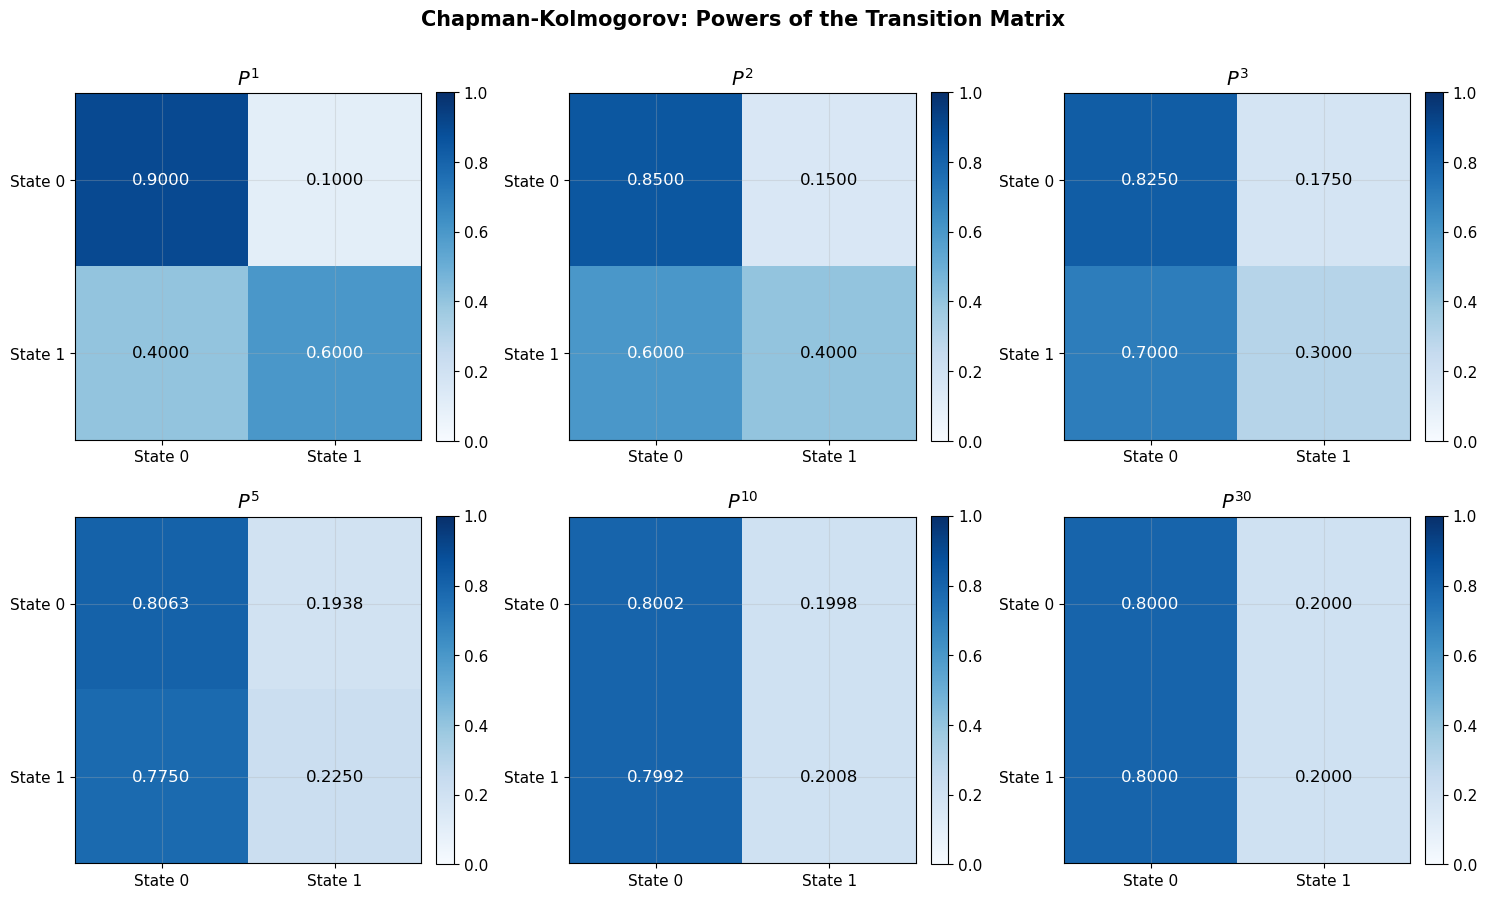

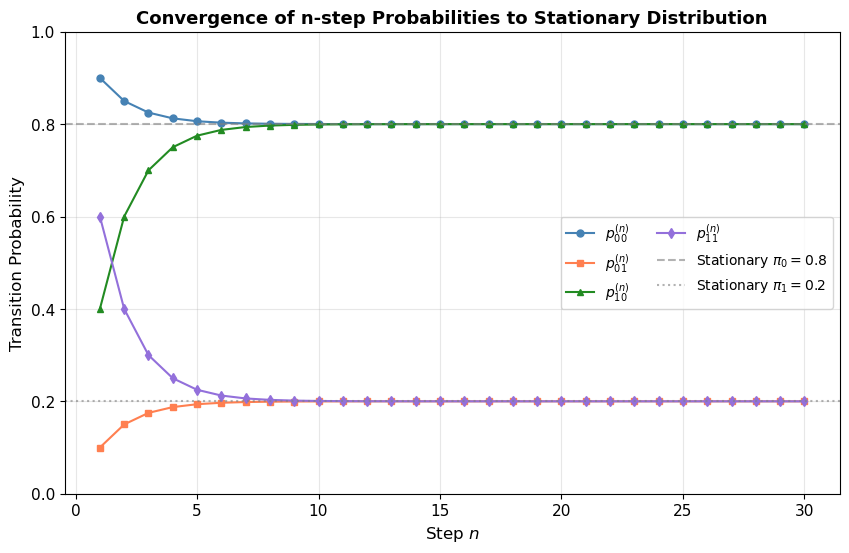

In [8]:
# ============================================================
# 3. Two-State Ergodic Chain: Matrix Powers & Verification
# ============================================================

np.random.seed(42)

# Transition matrix: persistent but leaky
P = np.array([[0.9, 0.1],
              [0.4, 0.6]])

print("One-step transition matrix P:")
print(P)
print()

# --- Numerical verification of Chapman-Kolmogorov ---
m, n = 3, 7
Pm = np.linalg.matrix_power(P, m)
Pn = np.linalg.matrix_power(P, n)
Pmn_direct = np.linalg.matrix_power(P, m + n)
Pmn_product = Pm @ Pn

print("Chapman-Kolmogorov Verification:")
print(f"  P^({m+n}) direct:")
print(Pmn_direct)
print(f"  P^{m} @ P^{n}:")
print(Pmn_product)
print(f"  Max absolute difference: {np.max(np.abs(Pmn_direct - Pmn_product)):.2e}")
print()

# --- Heatmap of matrix powers ---
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
n_values = [1, 2, 3, 5, 10, 30]

for idx, n in enumerate(n_values):
    Pn = np.linalg.matrix_power(P, n)
    ax = axes[idx]
    im = ax.imshow(Pn, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['State 0', 'State 1'])
    ax.set_yticklabels(['State 0', 'State 1'])
    
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{Pn[i, j]:.4f}', ha='center', va='center',
                    color='white' if Pn[i, j] > 0.5 else 'black', fontsize=12)
    
    ax.set_title(rf'$P^{{{n}}}$', fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Chapman-Kolmogorov: Powers of the Transition Matrix', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# --- Convergence to stationary distribution ---
fig, ax = plt.subplots(figsize=(10, 6))
n_max = 30
steps = range(1, n_max + 1)

p00 = [np.linalg.matrix_power(P, n)[0, 0] for n in steps]
p01 = [np.linalg.matrix_power(P, n)[0, 1] for n in steps]
p10 = [np.linalg.matrix_power(P, n)[1, 0] for n in steps]
p11 = [np.linalg.matrix_power(P, n)[1, 1] for n in steps]

# Stationary distribution: solve pi = pi P
# pi_0 = 0.8, pi_1 = 0.2
pi0, pi1 = 0.8, 0.2

ax.plot(steps, p00, 'o-', color='steelblue', markersize=5, label=r'$p_{00}^{(n)}$')
ax.plot(steps, p01, 's-', color='coral', markersize=5, label=r'$p_{01}^{(n)}$')
ax.plot(steps, p10, '^-', color='forestgreen', markersize=5, label=r'$p_{10}^{(n)}$')
ax.plot(steps, p11, 'd-', color='mediumpurple', markersize=5, label=r'$p_{11}^{(n)}$')

ax.axhline(y=pi0, color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label=r'Stationary $\pi_0 = 0.8$')
ax.axhline(y=pi1, color='gray', linestyle=':', linewidth=1.5, alpha=0.6, label=r'Stationary $\pi_1 = 0.2$')

ax.set_xlabel('Step $n$', fontsize=12)
ax.set_ylabel('Transition Probability', fontsize=12)
ax.set_title('Convergence of n-step Probabilities to Stationary Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, ncol=2)
ax.set_ylim(0, 1)
plt.show()


---
## **4. Larger State Spaces**

For a chain with more states, the Chapman-Kolmogorov equation is even more vivid: $P^n$ spreads probability mass across the state space, eventually smoothing out into the stationary distribution (if the chain is ergodic).

Consider a **birth-death chain** on 5 states $\{0,1,2,3,4\}$ with reflecting boundaries:

$$P = \begin{pmatrix}
0.50 & 0.50 & 0.00 & 0.00 & 0.00 \\
0.25 & 0.50 & 0.25 & 0.00 & 0.00 \\
0.00 & 0.25 & 0.50 & 0.25 & 0.00 \\
0.00 & 0.00 & 0.25 & 0.50 & 0.25 \\
0.00 & 0.00 & 0.00 & 0.50 & 0.50
\end{pmatrix}$$

Each row sums to 1. As $n \to \infty$, every row of $P^n$ converges to the same stationary distribution.


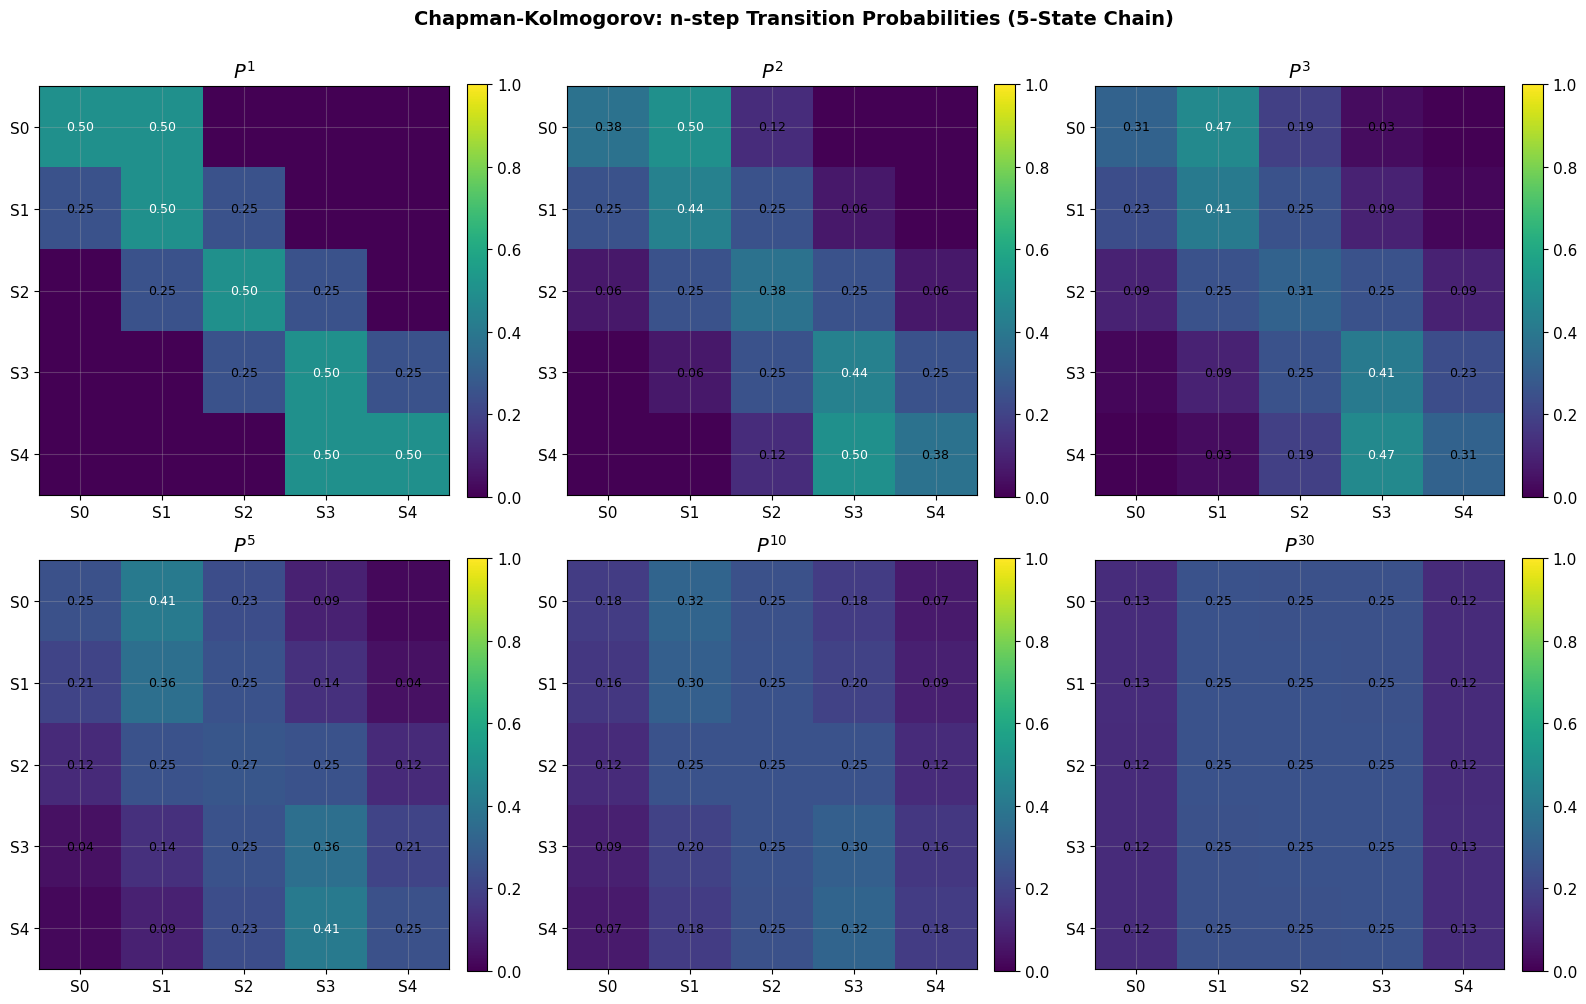

In [9]:
# ============================================================
# 5-State Birth-Death Chain: Evolution of P^n
# ============================================================

np.random.seed(7)

P5 = np.array([
    [0.50, 0.50, 0.00, 0.00, 0.00],
    [0.25, 0.50, 0.25, 0.00, 0.00],
    [0.00, 0.25, 0.50, 0.25, 0.00],
    [0.00, 0.00, 0.25, 0.50, 0.25],
    [0.00, 0.00, 0.00, 0.50, 0.50]
])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
n_values = [1, 2, 3, 5, 10, 30]

for idx, n in enumerate(n_values):
    Pn = np.linalg.matrix_power(P5, n)
    ax = axes[idx]
    im = ax.imshow(Pn, cmap='viridis', vmin=0, vmax=1)
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels([f'S{i}' for i in range(5)])
    ax.set_yticklabels([f'S{i}' for i in range(5)])
    ax.set_title(rf'$P^{{{n}}}$', fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    for i in range(5):
        for j in range(5):
            if Pn[i, j] > 0.02:
                ax.text(j, i, f'{Pn[i, j]:.2f}', ha='center', va='center',
                        color='white' if Pn[i, j] > 0.4 else 'black', fontsize=9)

plt.suptitle('Chapman-Kolmogorov: n-step Transition Probabilities (5-State Chain)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


---
## **5. Random Walk on the Integers**

For a **simple symmetric random walk** on $\mathbb{Z}$, the $n$-step transition probability from $0$ to $k$ is:

$$p_{0k}^{(n)} = \binom{n}{\frac{n+k}{2}} \left(\frac{1}{2}\right)^n$$

valid when $n+k$ is even and $|k| \leq n$; otherwise $p_{0k}^{(n)} = 0$.

This is the **binomial distribution** shifted to be centered at 0. By the Chapman-Kolmogorov equation, evolving for $m+n$ steps is equivalent to convolving the $m$-step distribution with the $n$-step distribution.


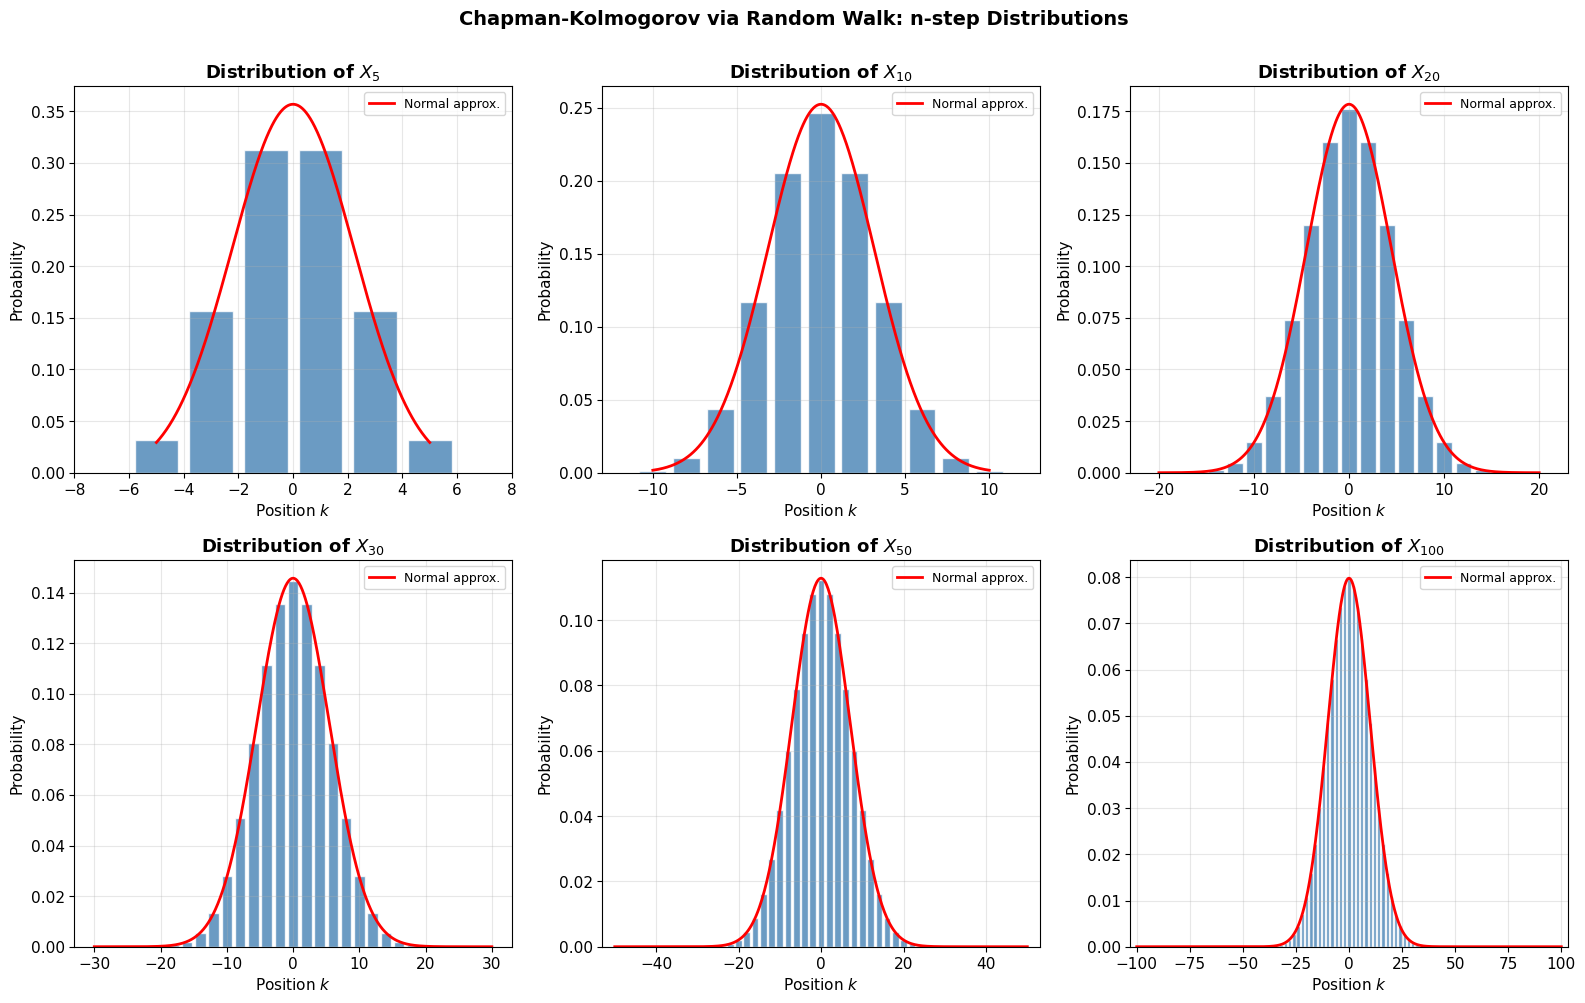

In [10]:
# ============================================================
# Random Walk PMF and Normal Approximation
# ============================================================

from math import comb

def random_walk_pmf(n, k):
    """P(X_n = k | X_0 = 0) for simple symmetric random walk."""
    if (n + k) % 2 != 0 or abs(k) > n:
        return 0.0
    return comb(n, (n + k) // 2) * (0.5 ** n)


np.random.seed(11)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
n_values = [5, 10, 20, 30, 50, 100]

for idx, n in enumerate(n_values):
    ax = axes[idx]
    k_values = list(range(-n, n + 1, 2))
    probs = [random_walk_pmf(n, k) for k in k_values]
    
    ax.bar(k_values, probs, color='steelblue', edgecolor='white', alpha=0.8, width=1.6)
    
    # Normal approximation (scaled by 2 because support spacing is 2)
    x = np.linspace(-n, n, 500)
    sigma = np.sqrt(n)
    y_approx = (2 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-x**2 / (2 * sigma**2))
    ax.plot(x, y_approx, 'r-', linewidth=2, label='Normal approx.')
    
    ax.set_title(rf'Distribution of $X_{{{n}}}$', fontsize=13, fontweight='bold')
    ax.set_xlabel('Position $k$', fontsize=11)
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_xlim(-n - 3, n + 3)
    ax.legend(fontsize=9)

plt.suptitle('Chapman-Kolmogorov via Random Walk: n-step Distributions',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


---
## **6. Convolution Semigroup**

For a random walk with step distribution $f$, the $n$-step distribution $f^{(n)}$ is the $n$-fold convolution:

$$f^{(n)} = f * f * \cdots * f \quad (n \text{ times})$$

The Chapman-Kolmogorov equation is precisely the statement that convolution is associative:

$$f^{(m+n)} = f^{(m)} * f^{(n)}$$

This makes the family of transition kernels $\{f^{(n)}\}_{n \geq 0}$ a **convolution semigroup**.

We demonstrate this with a **lazy random walk** on $\mathbb{Z}$ where each step is $-1, 0, +1$ with probabilities $\frac{1}{4}, \frac{1}{2}, \frac{1}{4}$.


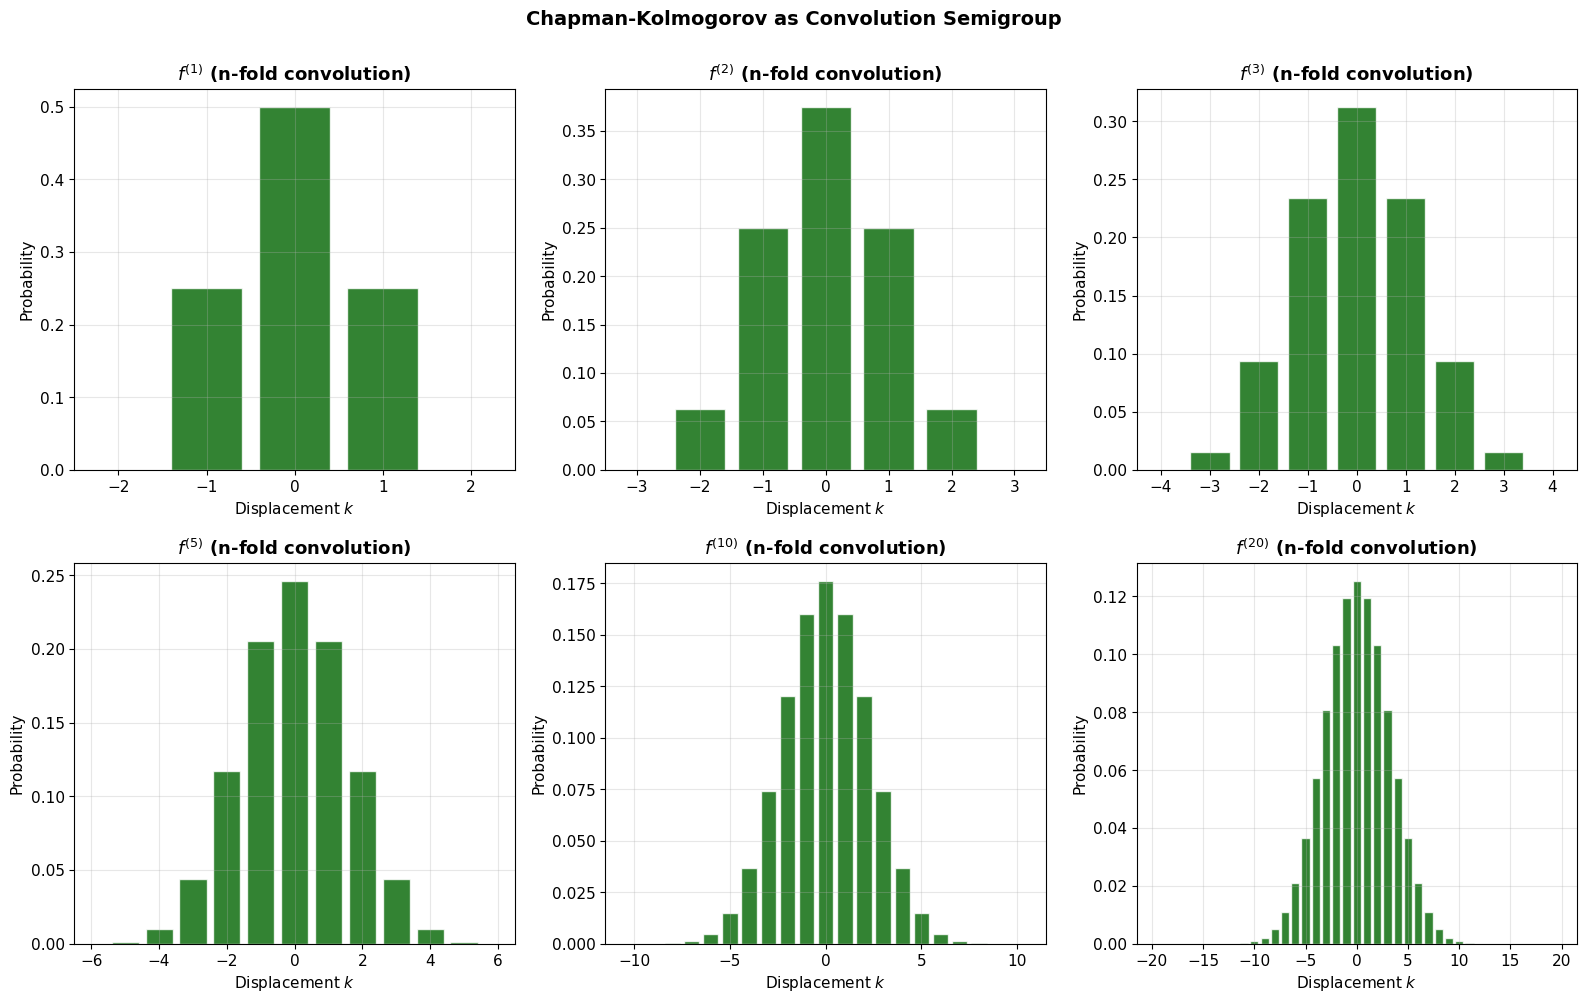

In [13]:
# ============================================================
# Convolution Semigroup: Lazy Random Walk
# ============================================================

def convolve_distributions(p, q):
    """Convolve two discrete distributions using FFT."""
    n = len(p) + len(q) - 1
    P = fft(p, n)
    Q = fft(q, n)
    return np.real(ifft(P * Q))


def n_fold_convolution(f, n):
    """Compute the n-fold self-convolution of f."""
    if n == 1:
        return f.copy()
    result = f.copy()
    for _ in range(n - 1):
        result = convolve_distributions(result, f)
    return result


np.random.seed(3)

# Step distribution: P(step = -1) = 1/4, P(step = 0) = 1/2, P(step = +1) = 1/4
f = np.array([0.25, 0.5, 0.25])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
n_values = [1, 2, 3, 5, 10, 20]

for idx, n in enumerate(n_values):
    fn = n_fold_convolution(f, n)
    k_values = np.arange(-n, n + 1)
    
    # fn should have length exactly 2*n + 1
    probs = fn[:2*n + 1]
    
    ax = axes[idx]
    ax.bar(k_values, probs, color='darkgreen', edgecolor='white', alpha=0.8, width=0.8)
    ax.set_title(rf'$f^{{({n})}}$ (n-fold convolution)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Displacement $k$', fontsize=11)
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_xlim(-n - 1.5, n + 1.5)

plt.suptitle('Chapman-Kolmogorov as Convolution Semigroup',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()



---
## **7. Continuous-Time Extension**

For a continuous-time Markov process with transition density $p_t(x, y)$, the Chapman-Kolmogorov equation reads:

$$p_{s+t}(x, y) = \int_{-\infty}^{\infty} p_s(x, z) \, p_t(z, y) \, dz$$

The classic example is **Brownian motion**, whose transition density is the heat kernel:

$$p_t(x, y) = \frac{1}{\sqrt{2\pi t}} \exp\left(-\frac{(y-x)^2}{2t}\right)$$

This family satisfies $p_s * p_t = p_{s+t}$ exactly — the heat kernel forms a semigroup under convolution.


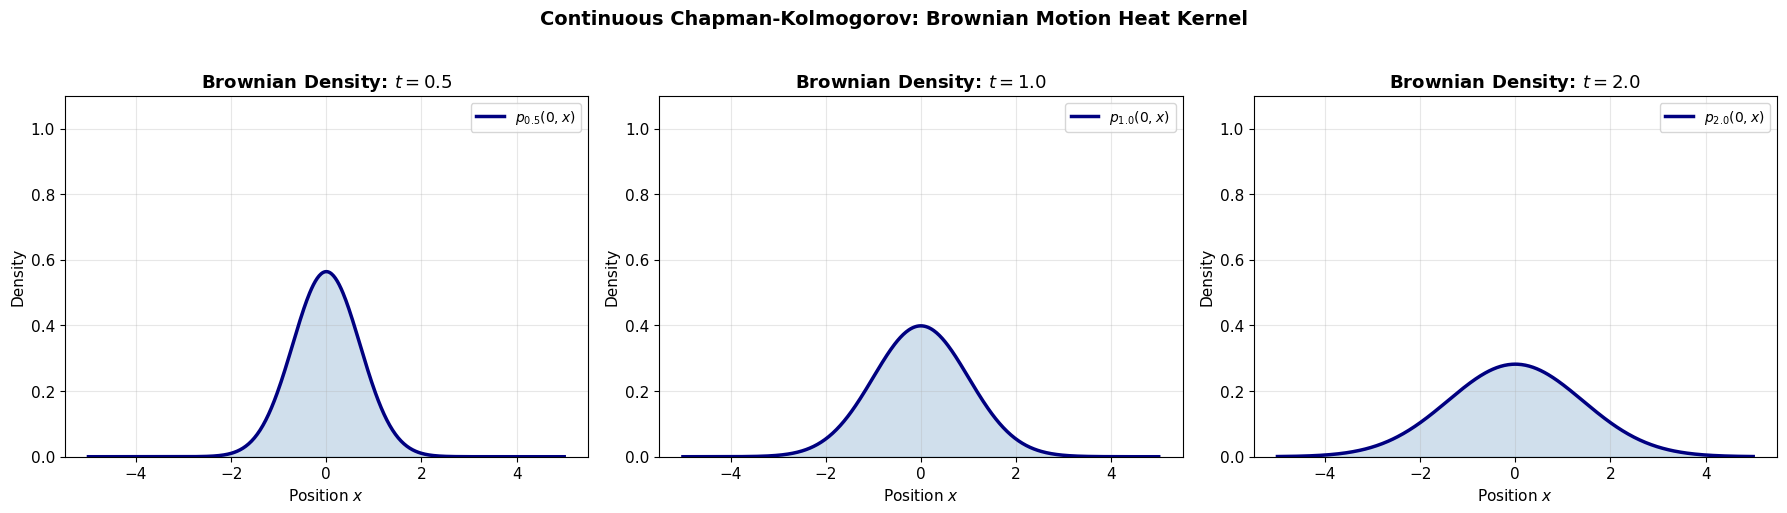

Continuous Chapman-Kolmogorov Verification:
  Integral  p_0.5(0,z) * p_1.0(z,1.5) dz = 0.15386632
  Direct    p_1.5(0,1.5)              = 0.15386632
  Relative error                                = 0.000000%


In [14]:
# ============================================================
# Continuous-Time: Brownian Motion Heat Kernel
# ============================================================

np.random.seed(5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
t_values = [0.5, 1.0, 2.0]
x0 = 0

for idx, t in enumerate(t_values):
    ax = axes[idx]
    x = np.linspace(-5, 5, 500)
    y = (1.0 / np.sqrt(2 * np.pi * t)) * np.exp(-(x - x0)**2 / (2 * t))
    
    ax.fill_between(x, y, alpha=0.25, color='steelblue')
    ax.plot(x, y, color='navy', linewidth=2.5, label=rf'$p_{{{t}}}(0, x)$')
    ax.set_title(rf'Brownian Density: $t = {t}$', fontsize=13, fontweight='bold')
    ax.set_xlabel('Position $x$', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=10)

plt.suptitle('Continuous Chapman-Kolmogorov: Brownian Motion Heat Kernel',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Numerical verification of the semigroup property ---
t1, t2 = 0.5, 1.0
x_grid = np.linspace(-12, 12, 4001)
dx = x_grid[1] - x_grid[0]
y_test = 1.5

# p_{t1}(0, z)
p1 = (1.0 / np.sqrt(2 * np.pi * t1)) * np.exp(-x_grid**2 / (2 * t1))

# p_{t2}(z, y_test) as a function of z
p2 = (1.0 / np.sqrt(2 * np.pi * t2)) * np.exp(-(y_test - x_grid)**2 / (2 * t2))

# Convolution integral via manual trapezoid
integrand = p1 * p2
conv_result = np.sum(integrand) * dx

# Direct evaluation p_{t1+t2}(0, y_test)
p_direct = (1.0 / np.sqrt(2 * np.pi * (t1 + t2))) * np.exp(-y_test**2 / (2 * (t1 + t2)))

print("Continuous Chapman-Kolmogorov Verification:")
print(f"  Integral  p_{t1}(0,z) * p_{t2}(z,{y_test}) dz = {conv_result:.8f}")
print(f"  Direct    p_{t1+t2}(0,{y_test})              = {p_direct:.8f}")
print(f"  Relative error                                = {abs(conv_result - p_direct)/p_direct * 100:.6f}%")


---
## **8. Summary**

| Concept | Key Formula | Interpretation |
|---------|-------------|----------------|
| **Discrete C-K** | $P^{(m+n)} = P^{(m)} P^{(n)}$ | Matrix semigroup |
| **n-step matrix** | $P^{(n)} = P^n$ | Repeated multiplication |
| **Random walk** | $p_{0k}^{(n)} = \binom{n}{(n+k)/2} 2^{-n}$ | Binomial PMF |
| **Convolution** | $f^{(m+n)} = f^{(m)} * f^{(n)}$ | Additive steps |
| **Continuous C-K** | $p_{s+t}(x,y) = \int p_s(x,z) p_t(z,y) dz$ | Heat kernel semigroup |

### References

1. **Norris, J.R.** (1998). *Markov Chains*. Cambridge University Press.
2. **Durrett, R.** (2019). *Probability: Theory and Examples* (5th ed.). Cambridge University Press.
3. **Karlin, S. & Taylor, H.M.** (1975). *A First Course in Stochastic Processes*. Academic Press.
4. **Liggett, T.M.** (2010). *Continuous Time Markov Processes*. AMS Graduate Studies in Mathematics.


